**GitHub Repository-** **https://github.com/anweshabose/Disease_Prediction_Model**

# **ANTICIPATING YOUR HEALTH**

![](https://diseasepredictionsite.netlify.app/img/background.jpg)

### **Take care of your Health because Blessings are not valued till they are gone.**

# **Introduction**

In this busy world, we often forget to spend time with ourselves. We often neglect our Health. Out of all works, it is very important to keep ourselves healthy. So, we have made an application by which you can check your Health or if you are suffering from any Disease. If Prediction anticipate any sort of Diseases, then please do not delay, do check up immediately. By this model, you will not have to spend a single penny to predict the disease that you are suffering from. You just have to put some efforts to provide few Symptoms that you have noticed in recent days about your Health and there you go for the Result.

In this project we have trained the model by Two different Algorithms and the best model is used to predict the Disease on the basis of Symptoms that you will provide. So, there is 100% chance that it will provide the accurate result. We will take a look at real world data and use machine learning techniques to build the model that can Predict the Disease.

# **Project Outline**

**Steps that we follow:**

- Installing and importing all the required libraries.
- Importing the csv file.
- Data Description.
- Data Processing
- i) Data Processing - Finding and filling Missing Values
- ii) Data Processing - Label Encoding
- Feature Scaling
- Prepare the Dataset for ML Training
- Model 1: Logistic Regression
- Model 2: Decision Tree Classifier
- Performance Evaluation
- Summary

# Installing and importing all the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [64]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score 
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score

# Importing the CSV file

In [67]:
df_train = pd.read_csv("train_data.csv")
df_train.head(5)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,disease
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [68]:
df_test = pd.read_csv("test_data.csv")
df_test.head(5)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,disease
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Allergy
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,GERD
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chronic cholestasis
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Drug Reaction


# Data Description

In [69]:
df_train.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,...,0.021951,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,...,0.146539,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [70]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to disease
dtypes: int64(132), object(1)
memory usage: 5.0+ MB


In [71]:
df_train.shape

(4920, 133)

# Data Processing

# i) Data Processing - Finding and filling Missing Values

In [72]:
df_train.isnull().sum()

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
disease                 0
Length: 133, dtype: int64

### Thus, all there are no Missing values.

# ii) Data Processing - Label Encoding

In [73]:
# Encode categorical variables
for column in df_train.columns[:-1]:  # Excluding target column ('disease')
    leb_encoder = LabelEncoder()
    df_train[column] = leb_encoder.fit_transform(df_train[column])

### Thus, all Categorical values are converted to Numerical values

# Feature Scaling
Feature Scaling is a technique used in machine learning to normalize or standardize numerical data so that features are on a similar scale.

In [74]:
# Standardizes the features by subtracting the mean and dividing by the standard deviation
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_train.drop('disease', axis=1))  
# Target variable should be excluded from scaling

# Prepare the Dataset for ML Training

In [75]:
# Define features and target variable
X_train = df_train.drop(columns=['disease'])     # X_train: Independent variable
y_train = df_train['disease']     # y_train: Dependent variable

X_test = df_train.drop(columns=['disease'])     # X_test: Independent variable
y_test = df_train['disease']     # y_test: Dependent variable

In [76]:
print(df_train.shape)
print(df_test.shape)

(4920, 133)
(42, 133)


In [77]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(4920, 132)
(4920,)
(4920, 132)
(4920,)


# **Model 1: Logistic Regression**

In [78]:
# Model Training: Here, we are training the model with X_train and y_train
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [79]:
# Predicting the trained-model on X_test to get the predicted values of y.
logistic_y_preds = log_model.predict(X_test)

In [80]:
# Logistic accuracy score: checking whether predicted values of y is equal to Actual values of y.
log_accuracy = accuracy_score(y_test, logistic_y_preds)
print(f"Logistic Regression Accuracy: {log_accuracy:.2f}")

Logistic Regression Accuracy: 1.00


### Accuracy: 1.00 means there is 100% match between Actual and Predicted values of y.

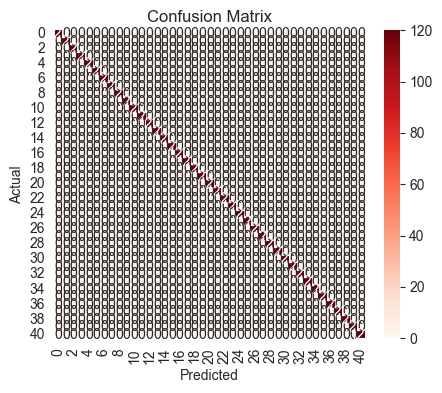

In [81]:
# Visualize Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, logistic_y_preds), annot=True, cmap='Reds', fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [82]:
print("Classification Report of Logistic Regression:")
print(classification_report(y_test, logistic_y_preds))

Classification Report of Logistic Regression:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00       120
                                   AIDS       1.00      1.00      1.00       120
                                   Acne       1.00      1.00      1.00       120
                    Alcoholic hepatitis       1.00      1.00      1.00       120
                                Allergy       1.00      1.00      1.00       120
                              Arthritis       1.00      1.00      1.00       120
                       Bronchial Asthma       1.00      1.00      1.00       120
                   Cervical spondylosis       1.00      1.00      1.00       120
                            Chicken pox       1.00      1.00      1.00       120
                    Chronic cholestasis       1.00      1.00      1.00       120
                            Common Cold       1.00      1.00  

# **Model 2: Decision Tree Classifier**

In [83]:
# Model Training: Here, we are training the model with X_train and y_train
Decision_Tree_model = DecisionTreeClassifier(random_state=42)
Decision_Tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [84]:
# Predicting the trained-model on X_test to get the predicted values of y.
Decision_Tree_y_preds = Decision_Tree_model.predict(X_test)

In [85]:
# Decision_Tree accuracy score: checking whether predicted values of y is equal to Actual values of y.
Decision_Tree_accuracy = accuracy_score(y_test, Decision_Tree_y_preds)
print(f"Decision_Tree Accuracy: {Decision_Tree_accuracy:.2f}")

Decision_Tree Accuracy: 1.00


### Accuracy: 1.00 means there is 100% match between Actual and Predicted values of y.

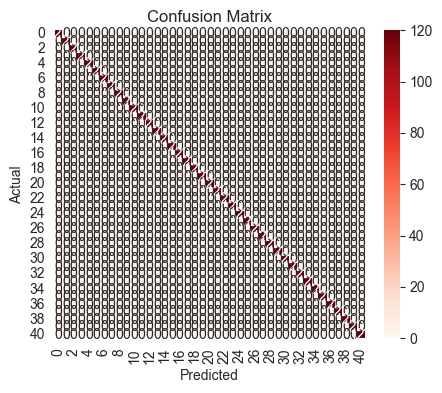

In [86]:
# Visualize Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, Decision_Tree_y_preds), annot=True, cmap='Reds', fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [87]:
print("Classification Report of Logistic Regression:")
print(classification_report(y_test, Decision_Tree_y_preds))

Classification Report of Logistic Regression:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00       120
                                   AIDS       1.00      1.00      1.00       120
                                   Acne       1.00      1.00      1.00       120
                    Alcoholic hepatitis       1.00      1.00      1.00       120
                                Allergy       1.00      1.00      1.00       120
                              Arthritis       1.00      1.00      1.00       120
                       Bronchial Asthma       1.00      1.00      1.00       120
                   Cervical spondylosis       1.00      1.00      1.00       120
                            Chicken pox       1.00      1.00      1.00       120
                    Chronic cholestasis       1.00      1.00      1.00       120
                            Common Cold       1.00      1.00  

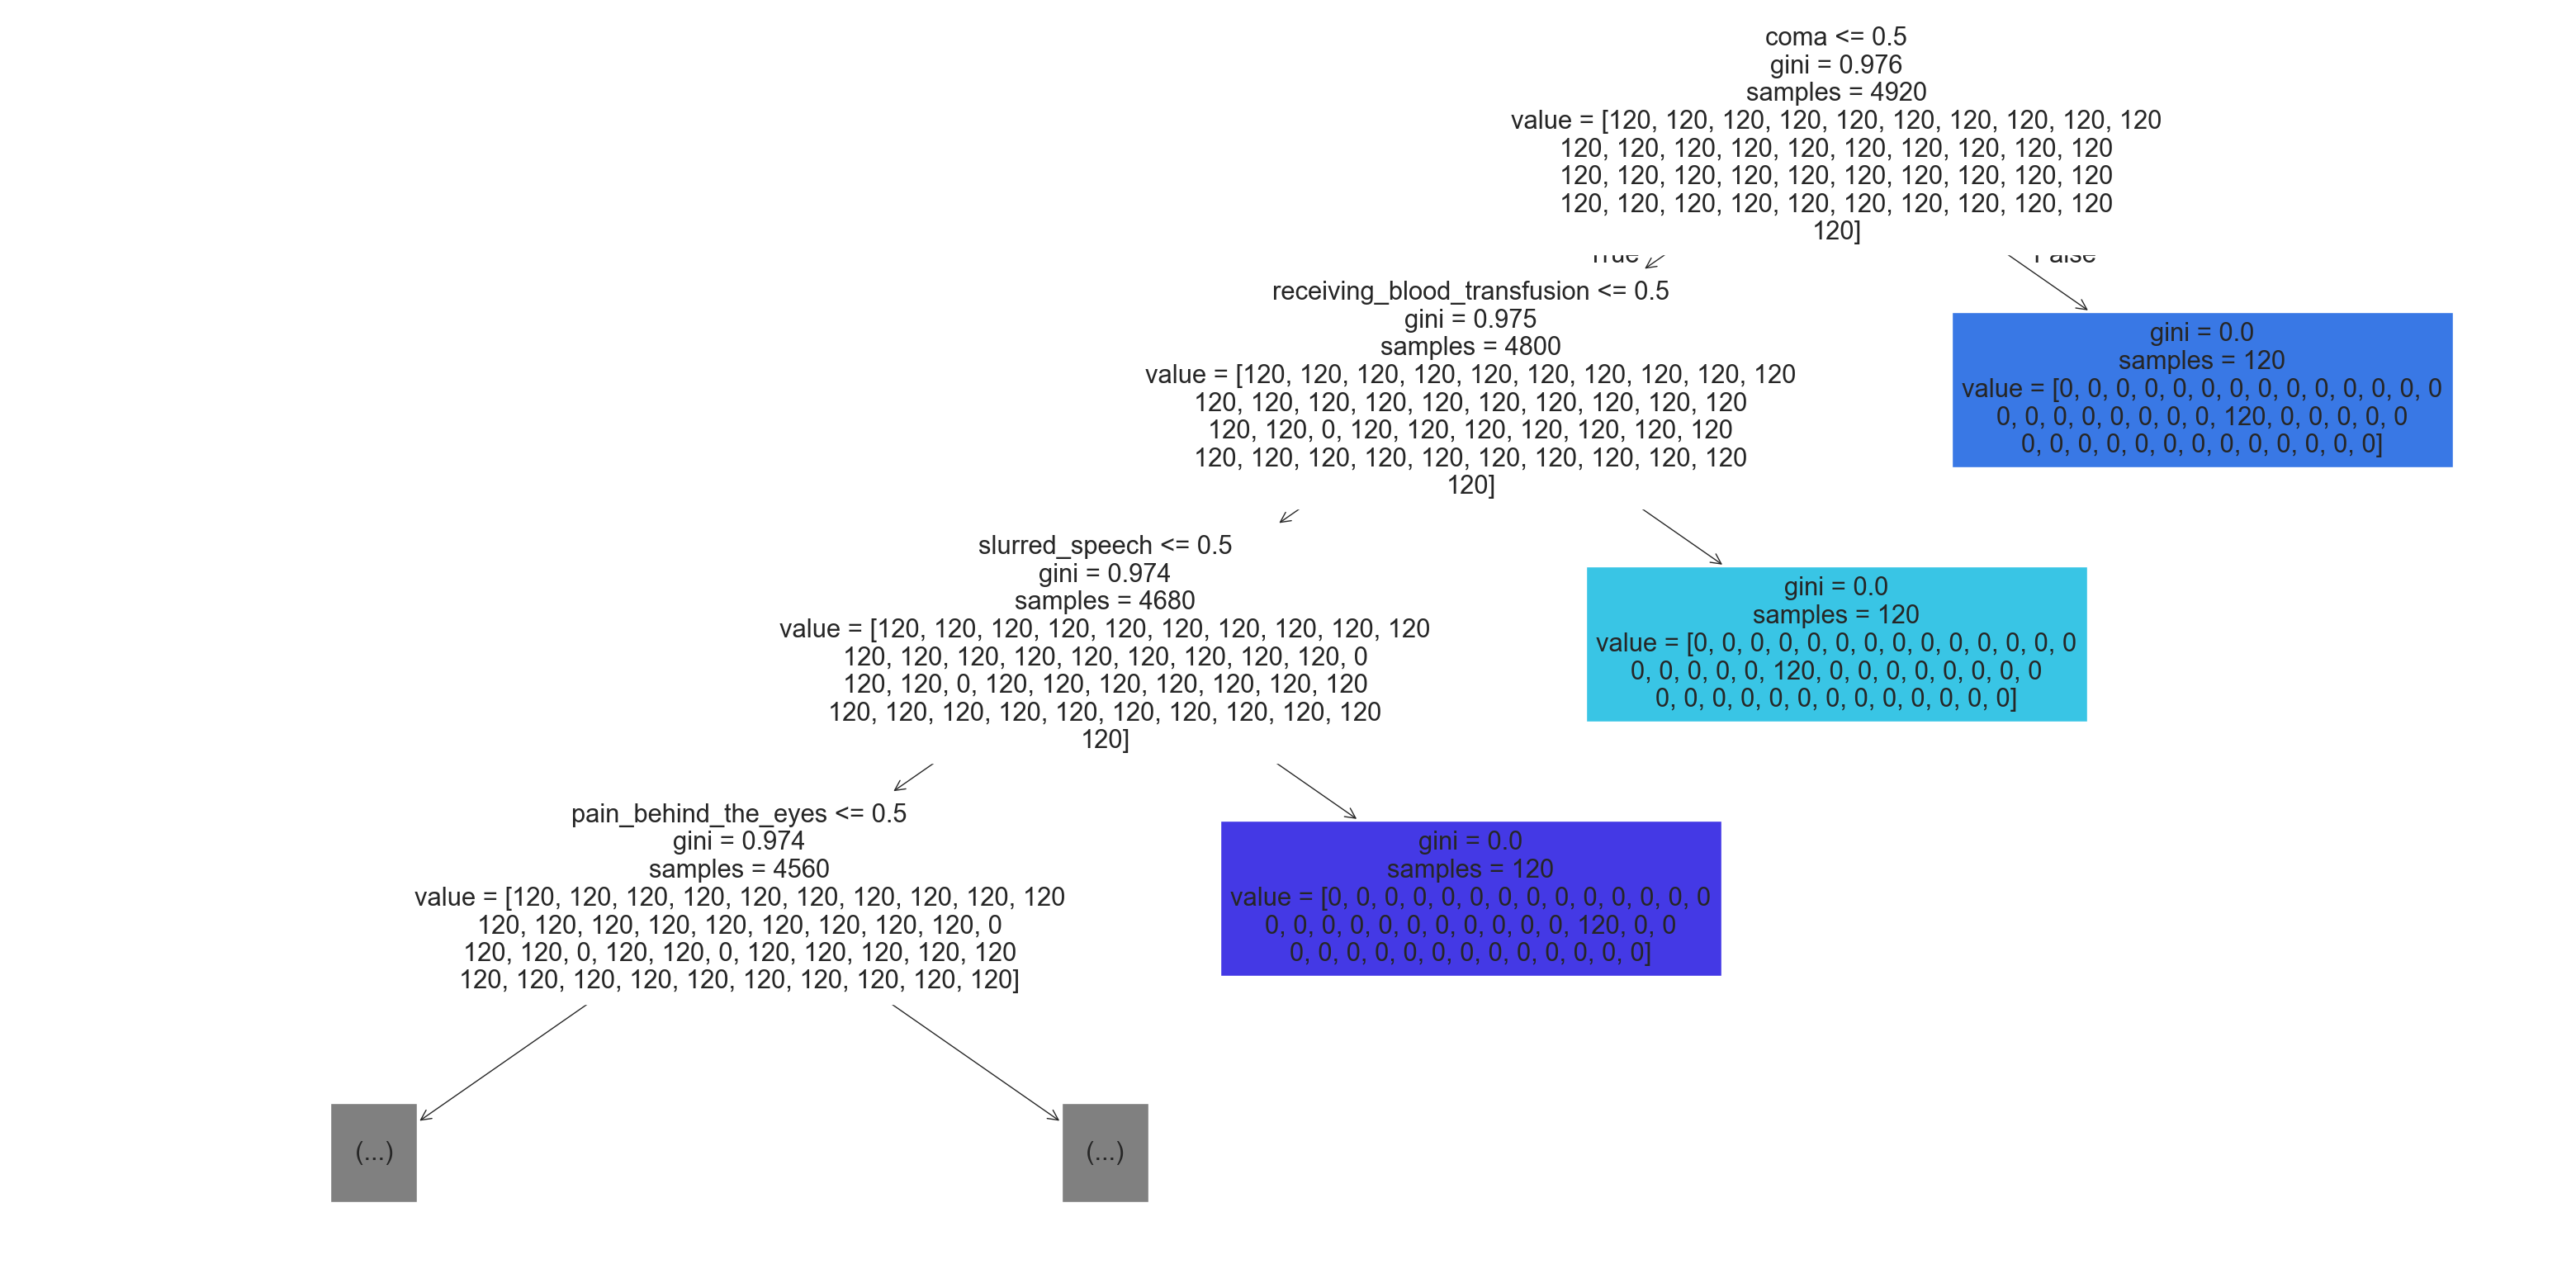

In [88]:
# Visualising the Decision Tree
from sklearn.tree import plot_tree
plt.figure(figsize=(40,20))
plot_tree(Decision_Tree_model, feature_names=X_train.columns, max_depth=3, filled=True)
plt.show()

## Model Performance Evaluation

In [89]:
accuracy_list = []
precision_list = []
f1_score_list = []
recall_list = []

In [90]:
accuracy_list.append(accuracy_score(y_test, logistic_y_preds))
precision_list.append(precision_score(y_test, logistic_y_preds, average='weighted'))
recall_list.append(recall_score(y_test, logistic_y_preds, average='weighted'))
f1_score_list.append(f1_score(y_test, logistic_y_preds, average='weighted'))

In [91]:
accuracy_list.append(accuracy_score(y_test, Decision_Tree_y_preds))
precision_list.append(precision_score(y_test, Decision_Tree_y_preds, average='weighted'))
recall_list.append(recall_score(y_test, Decision_Tree_y_preds, average='weighted'))
f1_score_list.append(f1_score(y_test, Decision_Tree_y_preds, average='weighted'))

In [92]:
print(accuracy_list)
print(precision_list)
print(recall_list)
print(f1_score_list)

[1.0, 1.0]
[1.0, 1.0]
[1.0, 1.0]
[1.0, 1.0]


In [93]:
labels = ['Logistic Reg', 'Decision Tree']

Text(0.5, 1.0, 'F1 Score')

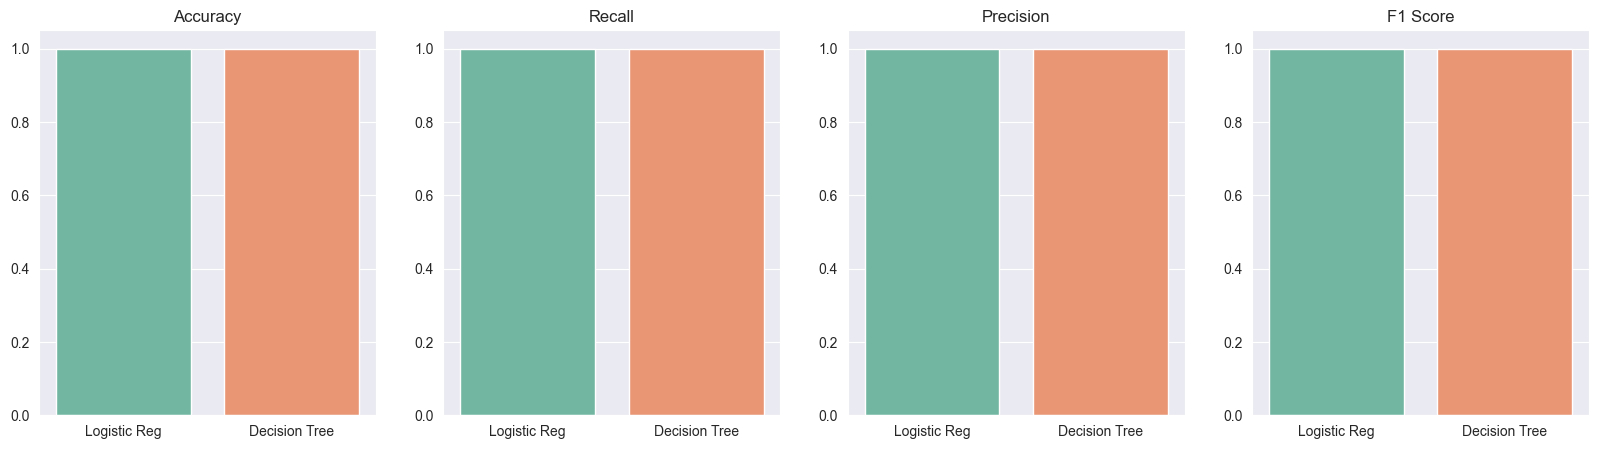

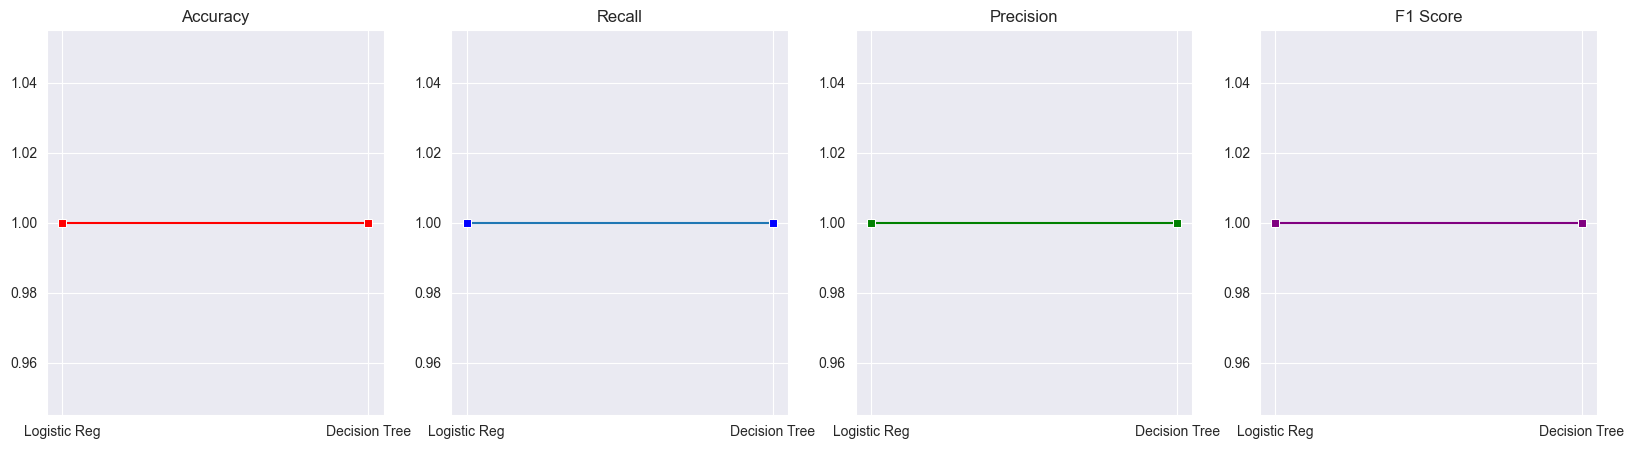

In [94]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))
sns.set_style('darkgrid')
sns.barplot(x = labels, y = accuracy_list, palette = 'Set2', ax = ax[0]).set_title("Accuracy")
sns.barplot(x = labels, y = recall_list, palette = 'Set2', ax = ax[1]).set_title("Recall")
sns.barplot(x = labels, y = precision_list, palette = 'Set2', ax = ax[2]).set_title("Precision")
sns.barplot(x = labels, y = f1_score_list, palette = 'Set2', ax = ax[3]).set_title("F1 Score")

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
sns.set_style('darkgrid')
sns.lineplot(x = labels, y = accuracy_list, palette = 'Set2', ax = ax[0], marker = 's', color = 'red').set_title("Accuracy")
sns.lineplot(x = labels, y = recall_list, palette = 'Set2', ax = ax[1], marker = 's', markerfacecolor = 'blue').set_title("Recall")
sns.lineplot(x = labels, y = precision_list, palette = 'Set2', ax = ax[2], marker = 's', color = 'green').set_title("Precision")
sns.lineplot(x = labels, y = f1_score_list, palette = 'Set2', ax = ax[3], marker = 's', color = 'purple').set_title("F1 Score")

### *In conclusion, disease predictions using machine learning algorithms, specifically Logistic Regression and Decision Tree, has provided valuable insights into their performance. Through rigorous evaluation and comparison, it is evident that Logistic Regression and Decision Tree both emerges as the effective algorithm for predicting diseases because tha accuracy of both the algorithm is 100%.*

# **Summary**

We downloaded, explored, observed for any missing values and trained 2 models to search the best model out of it and used that perticular model/algorithm for Disease Prediction.

- Train Dataset contains 4920 rows and 133 columns.
- Test Dataset contains 42 rows and 133 columns.
- Normalized the entire Data.
- Then split two datasets into X and y.
- Trained the model to perform the required Application of predicting Diseases correctly.
- Trained 2 models: `LogisticRegression` and `DecisionTree`.
Suprisingly, Both Model's performance was excellent because accuracy score of both model is 100%.
So we choose any of these two algorithm to predict disease in New Data. Lets say, we choose `DecisionTree`.

### **Now you can also predict your Disease just by providing 6 Symptoms that you are suffering from. 😊**

## **THANK YOU 😊**

# **No Wait ✋!! Summary is not Concluding the project.**
# **This is where My Project Begins....**
Go to 2-Disease_Prediction_Model.py file and run it. Command "streamlit run 2-Disease_Prediction_Model.py" and there you go, you will see the Magic.
# Good Day! 😊